In [1]:
from QKRR import load_fashion_mnist, NumericalTestRisk, TheoreticalTestRisk

## Set common parameters across numerical and theoretical plots

In [2]:
N_QUBITS = 3
LAMBDA_LIST = [1e-10, 1e-8, 1e-6, 1e-4, 1e-2]

X_train, y_train, X_test, y_test = load_fashion_mnist(N_QUBITS=N_QUBITS)
print(
    f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}, X_test shape: {X_test.shape}, y_test shape: {y_test.shape}"
)

Loading from cache: /Users/kkensuke/.cache/DD_QKRR/fashion_mnist.npz
X_train shape: (8991, 6), y_train shape: (8991,), X_test shape: (5009, 6), y_test shape: (5009,)


## Numerical Test Risk

In [3]:
# REPS=100

# numerical_tester = NumericalTestRisk(N_QUBITS=N_QUBITS, LAMBDA_LIST=LAMBDA_LIST, REPS=REPS, TPA=True)
# numerical_tester.numerical_test_risk_lambda_optimized(X_train, y_train, X_test[:1000], y_test[:1000])
# numerical_tester.save_results("results/QKRR_mnist_3qubits_TPA_numerical.pkl")

In [4]:
numerical_tester = NumericalTestRisk(N_QUBITS=N_QUBITS, LAMBDA_LIST=LAMBDA_LIST, TPA=True)
numerical_tester.load_results(
    "results/QKRR_mnist_3qubits_TPA_numerical.pkl"
)

Training sample sizes: [17, 20, 24, 27, 30, 34]


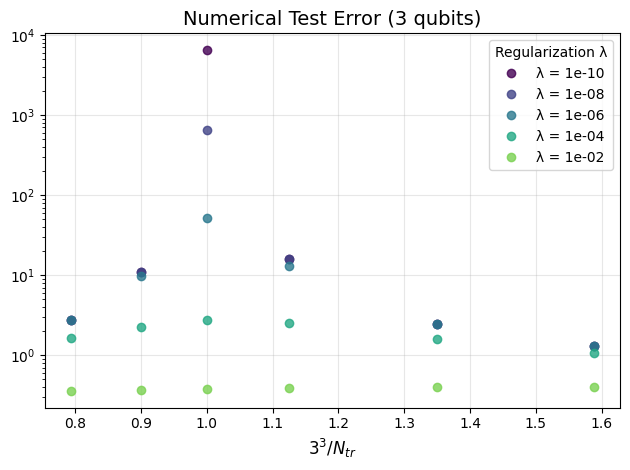

In [5]:
numerical_tester.plot_mse_test()

## Theoretical Test Risk

In [ ]:
# theoretical_tester = TheoreticalTestRisk(N_QUBITS=N_QUBITS, LAMBDA_LIST=LAMBDA_LIST, noise_sigma=0.07, TPA=True)

# theoretical_tester.theoretical_test_risk_lambda(X_test[1000:4000], y_test[1000:4000])
# theoretical_tester.save_results("results/QKRR_mnist_3qubits_TPA_theoretical.pkl")


λ = 1e-10
  n_train = 35
λ = 1e-08
  n_train = 35
λ = 1e-06
  n_train = 35
λ = 0.0001
  n_train = 35
λ = 0.01


In [ ]:
theoretical_tester = TheoreticalTestRisk()
theoretical_tester.load_results(
    "results/QKRR_mnist_3qubits_TPA_theoretical.pkl"
)

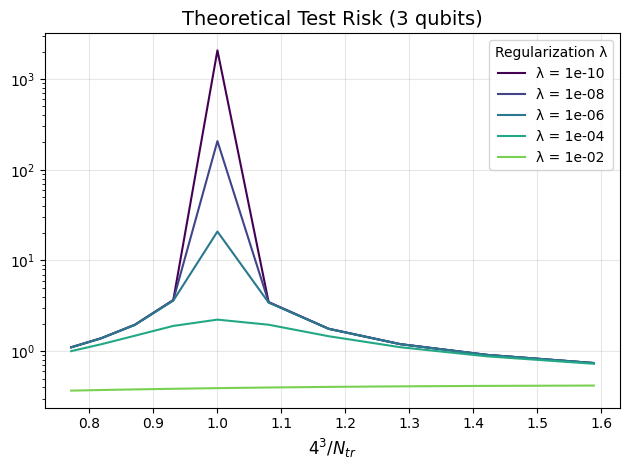

In [8]:
theoretical_tester.plot_theoretical_test()

In [9]:
# theoretical_tester.plot_effective_DOF()

<>:41: SyntaxWarning: invalid escape sequence '\g'
<>:41: SyntaxWarning: invalid escape sequence '\g'
/var/folders/9k/y9ch3jl55qd4kn1j6b53yyjw0000gn/T/ipykernel_87362/4188126926.py:41: SyntaxWarning: invalid escape sequence '\g'
  plt.xlabel(f"$\gamma = 3^{N_QUBITS}/N_{{tr}}$", fontsize=18)


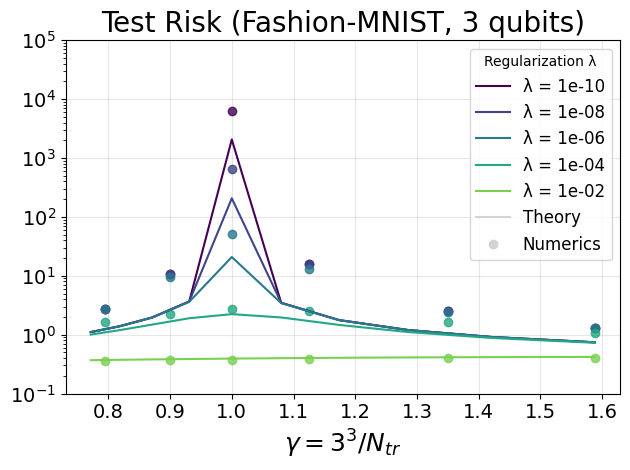

In [10]:
import numpy as np
import matplotlib.pyplot as plt

colors = plt.cm.viridis(np.linspace(0, 0.8, len(LAMBDA_LIST)))
numerical_ratio_list = 3**N_QUBITS / np.array(numerical_tester.n_train_list)
theoretical_ratio_list = 3**N_QUBITS / np.array(theoretical_tester.n_train_list)

for i, lam in enumerate(LAMBDA_LIST):
    plt.semilogy(
        numerical_ratio_list,
        numerical_tester.mse_test_all_mean[lam],
        marker="o",
        alpha=0.8,
        linestyle="none",
        color=colors[i],
    )

    # plt.errorbar(
    #     numerical_ratio_list,
    #     numerical_tester.mse_test_all_mean[lam],
    #     yerr=numerical_tester.mse_test_all_std[lam],
    #     marker="o",
    #     capsize=3,
    #     alpha=0.8,
    #     linestyle="none",
    #     color=colors[i],
    # )

for i, lam in enumerate(LAMBDA_LIST):
    plt.semilogy(
        theoretical_ratio_list,
        theoretical_tester.R_theoretical_list[i],
        label=f"λ = {lam:.0e}",
        color=colors[i],
    )

plt.plot([], [], "-", color="lightgray", label="Theory")
plt.plot([], [], "o", color="lightgray", label="Numerics")

# plt.yscale('log')
plt.xlabel(f"$\gamma = 3^{N_QUBITS}/N_{{tr}}$", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(1e-1, 1e5)
plt.title(f"Test Risk ({N_QUBITS} qubits)", fontsize=20)
plt.title(f"Test Risk (Fashion-MNIST, {N_QUBITS} qubits)", fontsize=20)
plt.legend(title="Regularization λ", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"results/QKRR_mnist_{N_QUBITS}qubits_TPA.pdf")